In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/transactions_in_usd.csv")

df.head()

,ATM Name,Transaction Date,No Of Withdrawals,No Of XYZ Card Withdrawals,No Of Other Card Withdrawals,Total amount Withdrawn,Amount withdrawn XYZ Card,Amount withdrawn Other Card,Weekday,Festival Religion,Working Day,Holiday Sequence
0,Big Street ATM,1/1/2011,50,20,30,2649.32,892.38,1756.94,Saturday,H,H,WHH
1,Mount Road ATM,1/1/2011,253,67,186,16433.06,5797.26,10635.80,Saturday,C,H,WHH
2,Airport ATM,1/1/2011,98,56,42,10772.76,7440.78,3331.98,Saturday,C,H,WHH
3,KK Nagar ATM,1/1/2011,265,159,106,20229.42,11397.64,8831.78,Saturday,C,H,WHH
4,Christ College ATM,1/1/2011,74,25,49,6156.78,3171.48,2985.30,Saturday,C,H,WHH


In [2]:
df.shape

(11589, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11589 entries, 0 to 11588
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ATM Name                      11589 non-null  object 
 1   Transaction Date              11589 non-null  object 
 2   No Of Withdrawals             11589 non-null  int64  
 3   No Of XYZ Card Withdrawals    11589 non-null  int64  
 4   No Of Other Card Withdrawals  11589 non-null  int64  
 5   Total amount Withdrawn        11589 non-null  float64
 6   Amount withdrawn XYZ Card     11589 non-null  float64
 7   Amount withdrawn Other Card   11589 non-null  float64
 8   Weekday                       11589 non-null  object 
 9   Festival Religion             11589 non-null  object 
 10  Working Day                   11589 non-null  object 
 11  Holiday Sequence              11589 non-null  object 
dtypes: float64(3), int64(3), object(6)
memory usage: 1.1+ MB


In [4]:
df.describe()

,No Of Withdrawals,No Of XYZ Card Withdrawals,No Of Other Card Withdrawals,Total amount Withdrawn,Amount withdrawn XYZ Card,Amount withdrawn Other Card
count,11589.000000,11589.000000,11589.000000,11589.000000,11589.000000,11589.000000
mean,123.341099,67.567694,55.773406,9003.043831,5800.089337,3202.954494
std,67.315288,47.849517,38.506475,5594.422849,4343.782745,2476.607646
min,1.000000,0.000000,0.000000,1.490000,0.000000,0.000000
25%,79.000000,34.000000,25.000000,5216.790000,2634.340000,1396.890000
50%,115.000000,57.000000,50.000000,8085.880000,4858.700000,2750.700000
75%,158.000000,87.000000,78.000000,11653.180000,7724.280000,4361.370000
max,491.000000,345.000000,310.000000,44556.490000,35675.860000,22678.040000


In [5]:
clean_df = df.copy()

In [6]:
clean_df.isnull().sum()

ATM Name                        0
Transaction Date                0
No Of Withdrawals               0
No Of XYZ Card Withdrawals      0
No Of Other Card Withdrawals    0
Total amount Withdrawn          0
Amount withdrawn XYZ Card       0
Amount withdrawn Other Card     0
Weekday                         0
Festival Religion               0
Working Day                     0
Holiday Sequence                0
dtype: int64

In [7]:
clean_df.duplicated().sum()

np.int64(0)

In [8]:
clean_df["ATM Name"].value_counts()

ATM Name
KK Nagar ATM          2371
Christ College ATM    2355
Big Street ATM        2354
Mount Road ATM        2256
Airport ATM           2253
Name: count, dtype: int64

In [9]:
clean_df["ATM Name"].nunique()

5

In [10]:
clean_df["Transaction Date"].head(10)


0    1/1/2011
1    1/1/2011
2    1/1/2011
3    1/1/2011
4    1/1/2011
5    2/1/2011
6    2/1/2011
7    2/1/2011
8    2/1/2011
9    2/1/2011
Name: Transaction Date, dtype: object

In [11]:
clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [12]:
print("Missing dates:", clean_df["Transaction Date"].isna().sum())

Missing dates: 0


In [13]:
print("Minimum date:", clean_df["Transaction Date"].min())
print("Maximum date:", clean_df["Transaction Date"].max())

Minimum date: 2011-01-01 00:00:00
Maximum date: 2017-09-29 00:00:00


In [14]:
clean_df["Weekday"]=clean_df["Transaction Date"].dt.day_name()

In [15]:
clean_df["Weekday"].value_counts()

Weekday
Wednesday    1677
Monday       1668
Thursday     1665
Tuesday      1657
Friday       1657
Saturday     1654
Sunday       1611
Name: count, dtype: int64

In [16]:
clean_df[["Transaction Date", "Weekday"]].head(10)

,Transaction Date,Weekday
0,2011-01-01,Saturday
1,2011-01-01,Saturday
2,2011-01-01,Saturday
3,2011-01-01,Saturday
4,2011-01-01,Saturday
5,2011-01-02,Sunday
6,2011-01-02,Sunday
7,2011-01-02,Sunday
8,2011-01-02,Sunday
9,2011-01-02,Sunday


In [17]:
clean_df["Year"] = clean_df["Transaction Date"].dt.year
clean_df["Month"] = clean_df["Transaction Date"].dt.month
clean_df["Day"] = clean_df["Transaction Date"].dt.day
clean_df["Day_of_Week"] = clean_df["Transaction Date"].dt.dayofweek
clean_df["Is_Weekend"] = (
    clean_df["Day_of_Week"] >= 5
).astype(int)

In [18]:
clean_df["Week_of_Year"] = (
    clean_df["Transaction Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

In [19]:
clean_df[
    [
        "ATM Name",
        "Transaction Date",
        "Weekday",
        "Year",
        "Month",
        "Day",
        "Day_of_Week",
        "Is_Weekend",
        "Week_of_Year"
    ]
].head(10)

,ATM Name,Transaction Date,Weekday,Year,Month,Day,Day_of_Week,Is_Weekend,Week_of_Year
0,Big Street ATM,2011-01-01,Saturday,2011,1,1,5,1,52
1,Mount Road ATM,2011-01-01,Saturday,2011,1,1,5,1,52
2,Airport ATM,2011-01-01,Saturday,2011,1,1,5,1,52
3,KK Nagar ATM,2011-01-01,Saturday,2011,1,1,5,1,52
4,Christ College ATM,2011-01-01,Saturday,2011,1,1,5,1,52
5,Big Street ATM,2011-01-02,Sunday,2011,1,2,6,1,52
6,Mount Road ATM,2011-01-02,Sunday,2011,1,2,6,1,52
7,Airport ATM,2011-01-02,Sunday,2011,1,2,6,1,52
8,KK Nagar ATM,2011-01-02,Sunday,2011,1,2,6,1,52
9,Christ College ATM,2011-01-02,Sunday,2011,1,2,6,1,52


#Check for duplicate values in copy dataset

In [20]:
clean_df.isnull().sum()

ATM Name                        0
Transaction Date                0
No Of Withdrawals               0
No Of XYZ Card Withdrawals      0
No Of Other Card Withdrawals    0
Total amount Withdrawn          0
Amount withdrawn XYZ Card       0
Amount withdrawn Other Card     0
Weekday                         0
Festival Religion               0
Working Day                     0
Holiday Sequence                0
Year                            0
Month                           0
Day                             0
Day_of_Week                     0
Is_Weekend                      0
Week_of_Year                    0
dtype: int64

In [21]:
print("Duplicate rows:", clean_df.duplicated().sum())

Duplicate rows: 0


In [22]:
atm_date_duplicates = clean_df.duplicated(
    subset=["ATM Name", "Transaction Date"]
).sum()

print("Duplicate ATM-Date combinations:", atm_date_duplicates)

Duplicate ATM-Date combinations: 0


#Gaps in date of ATM

In [23]:
for atm in clean_df["ATM Name"].unique():
    atm_dates = clean_df.loc[
        clean_df["ATM Name"] == atm,
        "Transaction Date"
    ].sort_values()

    expected_dates = pd.date_range(
        start=atm_dates.min(),
        end=atm_dates.max(),
        freq="D"
    )

    missing_dates = expected_dates.difference(atm_dates)

    print(f"{atm}: {len(missing_dates)} missing dates")

Big Street ATM: 110 missing dates
Mount Road ATM: 208 missing dates
Airport ATM: 211 missing dates
KK Nagar ATM: 93 missing dates
Christ College ATM: 109 missing dates


In [24]:
for atm in clean_df["ATM Name"].unique():
    atm_dates = clean_df.loc[
        clean_df["ATM Name"] == atm,
        "Transaction Date"
    ].sort_values()

    expected_dates = pd.date_range(
        start=atm_dates.min(),
        end=atm_dates.max(),
        freq="D"
    )

    missing_dates = expected_dates.difference(atm_dates)

    print("\n", atm)
    print(missing_dates[:20])


 Big Street ATM
DatetimeIndex(['2011-10-06', '2011-11-12', '2012-08-18', '2012-11-18',
               '2013-05-26', '2013-08-15', '2013-12-13', '2013-12-14',
               '2013-12-15', '2013-12-16', '2013-12-17', '2013-12-18',
               '2013-12-19', '2013-12-20', '2013-12-21', '2013-12-22',
               '2014-04-01', '2014-08-10', '2014-10-06', '2015-03-09'],
              dtype='datetime64[ns]', freq=None)

 Mount Road ATM
DatetimeIndex(['2012-06-17', '2012-08-20', '2013-01-27', '2013-03-10',
               '2013-04-22', '2013-12-13', '2013-12-14', '2013-12-15',
               '2013-12-16', '2013-12-17', '2013-12-18', '2013-12-19',
               '2013-12-20', '2013-12-21', '2013-12-22', '2014-04-01',
               '2015-07-19', '2015-12-03', '2015-12-04', '2015-12-06'],
              dtype='datetime64[ns]', freq=None)

 Airport ATM
DatetimeIndex(['2013-12-13', '2013-12-14', '2013-12-15', '2013-12-16',
               '2013-12-17', '2013-12-18', '2013-12-19', '2013-12-20',


In [25]:
for atm in clean_df["ATM Name"].unique():

    atm_dates = (
        clean_df.loc[
            clean_df["ATM Name"] == atm,
            "Transaction Date"
        ]
        .sort_values()
        .drop_duplicates()
    )

    full_range = pd.date_range(
        atm_dates.min(),
        atm_dates.max(),
        freq="D"
    )

    missing = full_range.difference(atm_dates)

    if len(missing) == 0:
        print(atm, "→ No missing dates")
        continue

    groups = missing.to_series().diff().ne(
        pd.Timedelta(days=1)
    ).cumsum()

    gap_lengths = missing.to_series().groupby(groups).size()

    print(
        atm,
        "→ Longest consecutive gap:",
        gap_lengths.max(),
        "days"
    )

Big Street ATM → Longest consecutive gap: 46 days
Mount Road ATM → Longest consecutive gap: 49 days
Airport ATM → Longest consecutive gap: 31 days
KK Nagar ATM → Longest consecutive gap: 19 days
Christ College ATM → Longest consecutive gap: 43 days


In [26]:
clean_df["Total amount Withdrawn"].describe()

count    11589.000000
mean      9003.043831
std       5594.422849
min          1.490000
25%       5216.790000
50%       8085.880000
75%      11653.180000
max      44556.490000
Name: Total amount Withdrawn, dtype: float64

#Boxplot

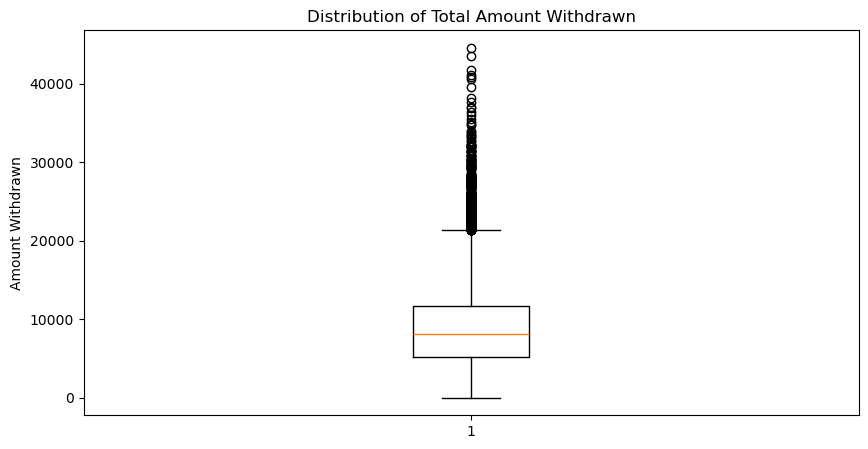

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.boxplot(clean_df["Total amount Withdrawn"].dropna())
plt.title("Distribution of Total Amount Withdrawn")
plt.ylabel("Amount Withdrawn")
plt.show()

In [28]:
clean_df[
    [
        "ATM Name",
        "Transaction Date",
        "No Of Withdrawals",
        "Total amount Withdrawn"
    ]
].sort_values(
    "Total amount Withdrawn",
    ascending=False
).head(10)

,ATM Name,Transaction Date,No Of Withdrawals,Total amount Withdrawn
3348,KK Nagar ATM,2012-11-01,410,44556.49
4309,KK Nagar ATM,2013-05-13,444,43527.84
4423,KK Nagar ATM,2013-06-05,404,41740.14
4254,KK Nagar ATM,2013-05-02,418,41152.50
6772,KK Nagar ATM,2014-10-01,480,40796.80
3043,KK Nagar ATM,2012-09-01,414,40567.78
2740,KK Nagar ATM,2012-07-02,400,39617.82
6168,KK Nagar ATM,2014-06-02,426,38208.00
3353,KK Nagar ATM,2012-11-02,370,37594.48
4553,KK Nagar ATM,2013-07-01,344,37024.86


In [29]:
Q1 = clean_df["Total amount Withdrawn"].quantile(0.25)
Q3 = clean_df["Total amount Withdrawn"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 5216.79
Q3: 11653.18
IQR: 6436.39
Lower bound: -4437.795000000001
Upper bound: 21307.765


In [30]:
outliers = clean_df[
    (clean_df["Total amount Withdrawn"] < lower_bound) |
    (clean_df["Total amount Withdrawn"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 434


In [31]:
print(
    "Percentage of potential outliers:",
    round(len(outliers) / len(clean_df) * 100, 2),
    "%"
)

Percentage of potential outliers: 3.74 %


In [32]:
outliers[
    [
        "ATM Name",
        "Transaction Date",
        "No Of Withdrawals",
        "Total amount Withdrawn",
        "Festival Religion",
        "Working Day",
        "Holiday Sequence"
    ]
].sort_values(
    "Total amount Withdrawn",
    ascending=False
).head(20)

,ATM Name,Transaction Date,No Of Withdrawals,Total amount Withdrawn,Festival Religion,Working Day,Holiday Sequence
3348,KK Nagar ATM,2012-11-01,410,44556.49,NH,H,HHW
4309,KK Nagar ATM,2013-05-13,444,43527.84,NH,W,HWW
4423,KK Nagar ATM,2013-06-05,404,41740.14,NH,W,WWW
4254,KK Nagar ATM,2013-05-02,418,41152.50,NH,W,HWW
6772,KK Nagar ATM,2014-10-01,480,40796.80,NH,W,WWH
3043,KK Nagar ATM,2012-09-01,414,40567.78,NH,H,WHH
2740,KK Nagar ATM,2012-07-02,400,39617.82,NH,H,HHW
6168,KK Nagar ATM,2014-06-02,426,38208.00,NH,W,HWW
3353,KK Nagar ATM,2012-11-02,370,37594.48,NH,H,HHW
4553,KK Nagar ATM,2013-07-01,344,37024.86,NH,W,HWW


In [33]:
clean_df["Demand_Outlier"] = (
    (clean_df["Total amount Withdrawn"] < lower_bound) |
    (clean_df["Total amount Withdrawn"] > upper_bound)
).astype(int)

In [34]:
clean_df["Demand_Outlier"].value_counts()

Demand_Outlier
0    11155
1      434
Name: count, dtype: int64

In [35]:
clean_df.columns


Index(['ATM Name', 'Transaction Date', 'No Of Withdrawals',
       'No Of XYZ Card Withdrawals', 'No Of Other Card Withdrawals',
       'Total amount Withdrawn', 'Amount withdrawn XYZ Card',
       'Amount withdrawn Other Card', 'Weekday', 'Festival Religion',
       'Working Day', 'Holiday Sequence', 'Year', 'Month', 'Day',
       'Day_of_Week', 'Is_Weekend', 'Week_of_Year', 'Demand_Outlier'],
      dtype='object')

In [36]:
clean_df = clean_df.sort_values(
    ["ATM Name", "Transaction Date"]
).reset_index(drop=True)

In [37]:
clean_df[
    ["ATM Name", "Transaction Date", "Total amount Withdrawn"]
].head(10)

,ATM Name,Transaction Date,Total amount Withdrawn
0,Airport ATM,2011-01-01,10772.76
1,Airport ATM,2011-01-02,5748.04
2,Airport ATM,2011-01-03,12923.46
3,Airport ATM,2011-01-04,11590.24
4,Airport ATM,2011-01-05,11342.00
5,Airport ATM,2011-01-06,9298.30
6,Airport ATM,2011-01-07,7164.72
7,Airport ATM,2011-01-08,11104.46
8,Airport ATM,2011-01-09,7213.94
9,Airport ATM,2011-01-10,9077.88


In [38]:
clean_df["Lag_1"] = (
    clean_df.groupby("ATM Name")["Total amount Withdrawn"]
    .shift(1)
)

In [39]:
clean_df["Lag_7"] = (
    clean_df.groupby("ATM Name")["Total amount Withdrawn"]
    .shift(7)
)

In [40]:
clean_df["Lag_14"] = (
    clean_df.groupby("ATM Name")["Total amount Withdrawn"]
    .shift(14)
)

In [41]:
clean_df["Lag_30"] = (
    clean_df.groupby("ATM Name")["Total amount Withdrawn"]
    .shift(30)
)

In [42]:
clean_df["Rolling_7_Mean"] = (
    clean_df.groupby("ATM Name")["Total amount Withdrawn"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [43]:
clean_df["Rolling_14_Mean"] = (
    clean_df.groupby("ATM Name")["Total amount Withdrawn"]
    .transform(
        lambda x: x.shift(1).rolling(14).mean()
    )
)

In [44]:
clean_df["Rolling_30_Mean"] = (
    clean_df.groupby("ATM Name")["Total amount Withdrawn"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

In [45]:
clean_df[
    [
        "ATM Name",
        "Transaction Date",
        "Total amount Withdrawn",
        "Lag_1",
        "Lag_7",
        "Lag_14",
        "Lag_30",
        "Rolling_7_Mean",
        "Rolling_14_Mean",
        "Rolling_30_Mean"
    ]
].head(40)

,ATM Name,Transaction Date,Total amount Withdrawn,Lag_1,Lag_7,Lag_14,Lag_30,Rolling_7_Mean,Rolling_14_Mean,Rolling_30_Mean
0,Airport ATM,2011-01-01,10772.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Airport ATM,2011-01-02,5748.04,10772.76,NaN,NaN,NaN,NaN,NaN,NaN
2,Airport ATM,2011-01-03,12923.46,5748.04,NaN,NaN,NaN,NaN,NaN,NaN
3,Airport ATM,2011-01-04,11590.24,12923.46,NaN,NaN,NaN,NaN,NaN,NaN
4,Airport ATM,2011-01-05,11342.00,11590.24,NaN,NaN,NaN,NaN,NaN,NaN
5,Airport ATM,2011-01-06,9298.30,11342.00,NaN,NaN,NaN,NaN,NaN,NaN
6,Airport ATM,2011-01-07,7164.72,9298.30,NaN,NaN,NaN,NaN,NaN,NaN
7,Airport ATM,2011-01-08,11104.46,7164.72,10772.76,NaN,NaN,9834.217143,NaN,NaN
8,Airport ATM,2011-01-09,7213.94,11104.46,5748.04,NaN,NaN,9881.602857,NaN,NaN
9,Airport ATM,2011-01-10,9077.88,7213.94,12923.46,NaN,NaN,10091.017143,NaN,NaN


In [46]:
clean_df[
    [
        "Lag_1",
        "Lag_7",
        "Lag_14",
        "Lag_30",
        "Rolling_7_Mean",
        "Rolling_14_Mean",
        "Rolling_30_Mean"
    ]
].isnull().sum()

Lag_1                5
Lag_7               35
Lag_14              70
Lag_30             150
Rolling_7_Mean      35
Rolling_14_Mean     70
Rolling_30_Mean    150
dtype: int64

In [47]:
clean_df.shape

(11589, 26)

#Create a seperate modeling dataset without null values

In [48]:
model_df = clean_df.dropna(
    subset=[
        "Lag_1",
        "Lag_7",
        "Lag_14",
        "Lag_30",
        "Rolling_7_Mean",
        "Rolling_14_Mean",
        "Rolling_30_Mean"
    ]
).copy()

In [49]:
print("Original rows:", len(clean_df))
print("Modeling rows:", len(model_df))

Original rows: 11589
Modeling rows: 11439


In [50]:
model_df[
    [
        "Lag_1",
        "Lag_7",
        "Lag_14",
        "Lag_30",
        "Rolling_7_Mean",
        "Rolling_14_Mean",
        "Rolling_30_Mean"
    ]
].isnull().sum()

Lag_1              0
Lag_7              0
Lag_14             0
Lag_30             0
Rolling_7_Mean     0
Rolling_14_Mean    0
Rolling_30_Mean    0
dtype: int64

In [51]:
all_dates = pd.date_range(
    clean_df["Transaction Date"].min(),
    clean_df["Transaction Date"].max(),
    freq="D"
)

all_atms = clean_df["ATM Name"].unique()

calendar_df = pd.MultiIndex.from_product(
    [all_atms, all_dates],
    names=["ATM Name", "Transaction Date"]
).to_frame(index=False)

print(calendar_df.shape)

(12320, 2)


In [52]:
calendar_df = calendar_df.merge(
    clean_df[
        [
            "ATM Name",
            "Transaction Date",
            "Total amount Withdrawn"
        ]
    ],
    on=["ATM Name", "Transaction Date"],
    how="left"
)

In [53]:
calendar_df.head()

,ATM Name,Transaction Date,Total amount Withdrawn
0,Airport ATM,2011-01-01,10772.76
1,Airport ATM,2011-01-02,5748.04
2,Airport ATM,2011-01-03,12923.46
3,Airport ATM,2011-01-04,11590.24
4,Airport ATM,2011-01-05,11342.00


In [54]:
for days in [1, 7, 14, 30]:
    calendar_df[f"Lag_{days}_Day"] = (
        calendar_df.groupby("ATM Name")["Total amount Withdrawn"]
        .shift(days)
    )

In [55]:
calendar_df["Previous_Day_Demand"] = (
    calendar_df.groupby("ATM Name")["Total amount Withdrawn"]
    .shift(1)
)
calendar_df["Rolling_7_Day_Mean"] = (
    calendar_df.groupby("ATM Name")["Previous_Day_Demand"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)
calendar_df["Rolling_14_Day_Mean"] = (
    calendar_df.groupby("ATM Name")["Previous_Day_Demand"]
    .transform(lambda x: x.rolling(14, min_periods=1).mean())
)
calendar_df["Rolling_30_Day_Mean"] = (
    calendar_df.groupby("ATM Name")["Previous_Day_Demand"]
    .transform(lambda x: x.rolling(30, min_periods=1).mean())
)

In [56]:
calendar_features = calendar_df[
    [
        "ATM Name",
        "Transaction Date",
        "Lag_1_Day",
        "Lag_7_Day",
        "Lag_14_Day",
        "Lag_30_Day",
        "Rolling_7_Day_Mean",
        "Rolling_14_Day_Mean",
        "Rolling_30_Day_Mean"
    ]
]

#Merge the clean df and calender value to get the final dataframe

In [57]:
final_df = clean_df.merge(
    calendar_features,
    on=["ATM Name", "Transaction Date"],
    how="left"
)

In [58]:
final_df.head()

,ATM Name,Transaction Date,No Of Withdrawals,No Of XYZ Card Withdrawals,No Of Other Card Withdrawals,Total amount Withdrawn,Amount withdrawn XYZ Card,Amount withdrawn Other Card,Weekday,Festival Religion,...,Rolling_7_Mean,Rolling_14_Mean,Rolling_30_Mean,Lag_1_Day,Lag_7_Day,Lag_14_Day,Lag_30_Day,Rolling_7_Day_Mean,Rolling_14_Day_Mean,Rolling_30_Day_Mean
0,Airport ATM,2011-01-01,98,56,42,10772.76,7440.78,3331.98,Saturday,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Airport ATM,2011-01-02,67,53,14,5748.04,4564.62,1183.42,Sunday,NH,...,NaN,NaN,NaN,10772.76,NaN,NaN,NaN,10772.760000,10772.760000,10772.760000
2,Airport ATM,2011-01-03,109,90,19,12923.46,10738.52,2184.94,Monday,NH,...,NaN,NaN,NaN,5748.04,NaN,NaN,NaN,8260.400000,8260.400000,8260.400000
3,Airport ATM,2011-01-04,113,80,33,11590.24,8953.76,2636.48,Tuesday,NH,...,NaN,NaN,NaN,12923.46,NaN,NaN,NaN,9814.753333,9814.753333,9814.753333
4,Airport ATM,2011-01-05,100,70,30,11342.00,9082.16,2259.84,Wednesday,NH,...,NaN,NaN,NaN,11590.24,NaN,NaN,NaN,10258.625000,10258.625000,10258.625000


In [59]:
final_df[
    [
        "Lag_1_Day",
        "Lag_7_Day",
        "Lag_14_Day",
        "Lag_30_Day",
        "Rolling_7_Day_Mean",
        "Rolling_14_Day_Mean",
        "Rolling_30_Day_Mean"
    ]
].isnull().sum()

Lag_1_Day              220
Lag_7_Day              422
Lag_14_Day             527
Lag_30_Day             660
Rolling_7_Day_Mean      27
Rolling_14_Day_Mean     12
Rolling_30_Day_Mean     10
dtype: int64

In [60]:
model_df = final_df.dropna(
    subset=[
        "Lag_1_Day",
        "Lag_7_Day",
        "Lag_14_Day",
        "Rolling_7_Day_Mean",
        "Rolling_14_Day_Mean",
        "Rolling_30_Day_Mean"
    ]
).copy()

In [61]:
print("Original rows:", len(final_df))
print("Modeling rows:", len(model_df))
print("Rows removed:", len(final_df) - len(model_df))

Original rows: 11589
Modeling rows: 10658
Rows removed: 931


In [62]:
model_df[
    [
        "Lag_1_Day",
        "Lag_7_Day",
        "Lag_14_Day",
        "Rolling_7_Day_Mean",
        "Rolling_14_Day_Mean",
        "Rolling_30_Day_Mean"
    ]
].isnull().sum()

Lag_1_Day              0
Lag_7_Day              0
Lag_14_Day             0
Rolling_7_Day_Mean     0
Rolling_14_Day_Mean    0
Rolling_30_Day_Mean    0
dtype: int64

In [64]:
model_df.to_csv(
    "../data/processed/atm_model_ready.csv",
    index=False
)